In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.append('../..')

In [3]:
import pylab as plt
import numpy as np

from stable_baselines3 import PPO

In [4]:
from vimms.Common import POSITIVE, set_log_level_warning
from vimms.ChemicalSamplers import UniformRTAndIntensitySampler, GaussianChromatogramSampler, UniformMZFormulaSampler

from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import run_method
from vimms_gym.common import METHOD_TOPN, METHOD_PPO
from vimms_gym.visualisation import plot_N, plot_ms1_ms2_counts, plot_action_hist, plot_action_probs, plot_reward_probs

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


# 1. Parameters

In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (2000, 5000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E4, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [9]:
mz_sampler = UniformMZFormulaSampler(min_mz=min_mz, max_mz=max_mz)
ri_sampler = UniformRTAndIntensitySampler(min_rt=min_rt, max_rt=max_rt,
                                          min_log_intensity=min_log_intensity,
                                          max_log_intensity=max_log_intensity)
cr_sampler = GaussianChromatogramSampler()
samplers = {
    'mz': mz_sampler,
    'rt_intensity': ri_sampler,
    'chromatogram': cr_sampler
}

In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [11]:
max_peaks = 200
in_dir = 'results'

In [12]:
n_eval_episodes = 1
deterministic = True

# 2. Evaluation

## Generate some chemical sets

In [13]:
set_log_level_warning()

1

In [14]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0


## Run different methods

In [15]:
eval_dir = 'visualisation'

In [16]:
for chems in chem_list:
    print(len(chems))

2222


In [17]:
max_peaks

200

In [18]:
out_dir = eval_dir
in_dir, out_dir

('results', 'visualisation')

In [19]:
all_results = {}

In [20]:
env_name = 'DDAEnv'

### Run PPO

In [21]:
method = METHOD_PPO

In [22]:
model_name = 'PPO'

In [23]:
effective_rt_tol = rt_tol
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [24]:
fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
model = PPO.load(fname)

In [25]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, model=model, print_eval=True, print_reward=True)


Episode 0 (2222 chemicals)
steps	 500 	total rewards	 107.9555865173824
steps	 1000 	total rewards	 262.8847856883076
steps	 1500 	total rewards	 406.17877084771555
steps	 2000 	total rewards	 534.8216637139469
steps	 2500 	total rewards	 674.5517736166152
steps	 3000 	total rewards	 813.6701579516657
Finished after 3202 timesteps with total reward 889.5855062338146
{'coverage_prop': '0.977', 'intensity_prop': '0.453', 'ms1/ms2 ratio': '0.332', 'efficiency': '0.902', 'TP': '748', 'FP': '1236', 'FN': '238', 'precision': '0.377', 'recall': '0.759', 'f1': '0.504'}


In [26]:
ppo_result = results[0]
ppo_result

### Run Top-N

In [27]:
method = METHOD_TOPN

In [28]:
effective_rt_tol = rt_tol
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [29]:
model = None

In [30]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, N=10, model=model, print_eval=True, print_reward=True)


Episode 0 (2222 chemicals)
steps	 500 	total rewards	 33.41984985340091
steps	 1000 	total rewards	 73.17835704311453
steps	 1500 	total rewards	 113.62742163800131
steps	 2000 	total rewards	 150.96750783650236
steps	 2500 	total rewards	 188.4497045954879
steps	 3000 	total rewards	 229.74617318828467
Finished after 3105 timesteps with total reward 238.97392898842378
{'coverage_prop': '0.995', 'intensity_prop': '0.164', 'ms1/ms2 ratio': '0.405', 'efficiency': '1.000', 'TP': '143', 'FP': '1865', 'FN': '214', 'precision': '0.071', 'recall': '0.401', 'f1': '0.121'}


In [31]:
topN_result = results[0]
topN_result

# 3. Visualisation

## Visualise some results from the first episode

Limit some plots to the first 1000 steps.

In [32]:
limit = 1000

Plot the distribution of N: the number of MS2 scans that follow an MS1 scan

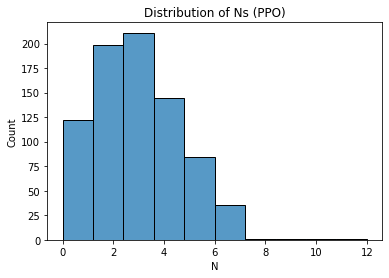

In [33]:
plot_N(ppo_result, bins=10, title='Distribution of Ns (PPO)')

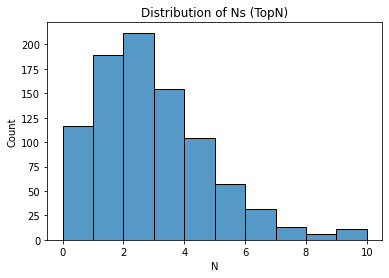

In [34]:
plot_N(topN_result, bins=10, title='Distribution of Ns (TopN)')

Plot the number of MS1 and MS2 scans over time

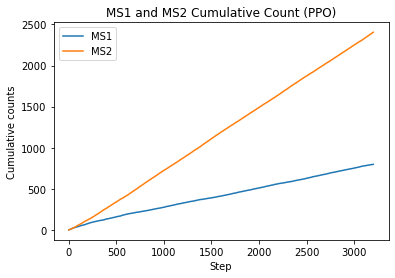

In [35]:
ppo_ms1, ppo_ms2 = plot_ms1_ms2_counts(ppo_result, title='MS1 and MS2 Cumulative Count (PPO)')

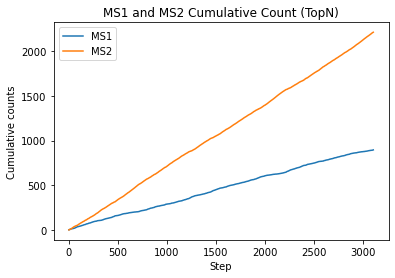

In [36]:
topN_ms1, topN_ms2 = plot_ms1_ms2_counts(topN_result, title='MS1 and MS2 Cumulative Count (TopN)')

Text(0.5, 1.0, 'MS2 Cumulative Counts')

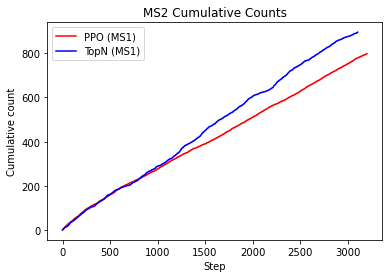

In [37]:
plt.plot(ppo_ms1, 'r-', label='PPO (MS1)')
plt.plot(topN_ms1, 'b-', label='TopN (MS1)')
plt.legend()
plt.ylabel('Cumulative count')
plt.xlabel('Step')
plt.title('MS2 Cumulative Counts')

Plot a histogram of all actions.

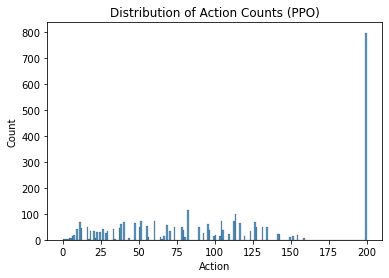

In [38]:
plot_action_hist(ppo_result, bins=200, title='Distribution of Action Counts (PPO)')

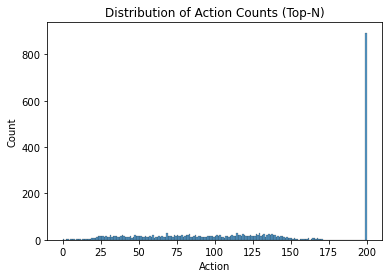

In [39]:
plot_action_hist(topN_result, bins=200, title='Distribution of Action Counts (Top-N)')

Plot a histogram of MS2-actions only

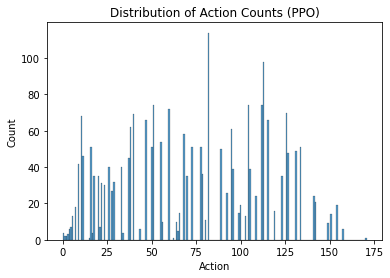

In [40]:
plot_action_hist(ppo_result, ms2_only=True, bins=199, title='Distribution of Action Counts (PPO)')

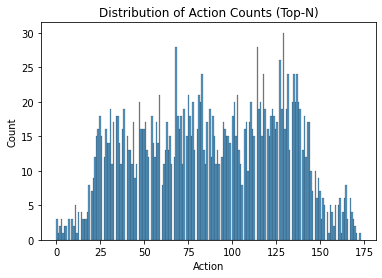

In [41]:
plot_action_hist(topN_result, ms2_only=True, bins=199, title='Distribution of Action Counts (Top-N)')

Show the first few actions

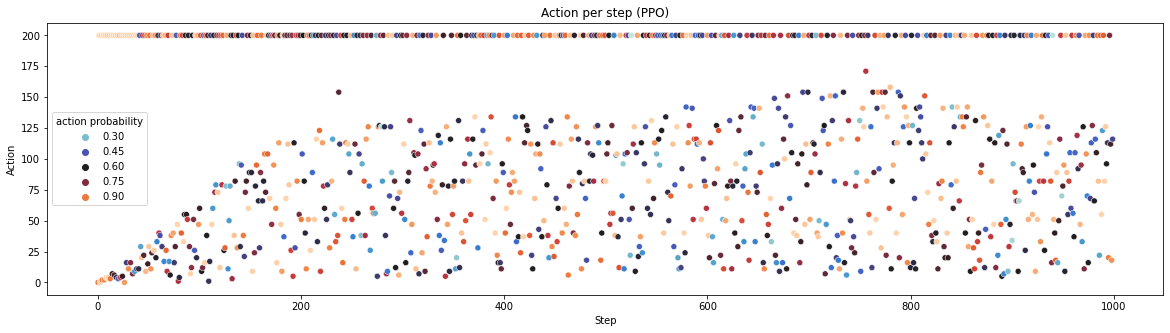

In [42]:
plot_action_probs(ppo_result, limit, max_peaks, title='Action per step (PPO)')

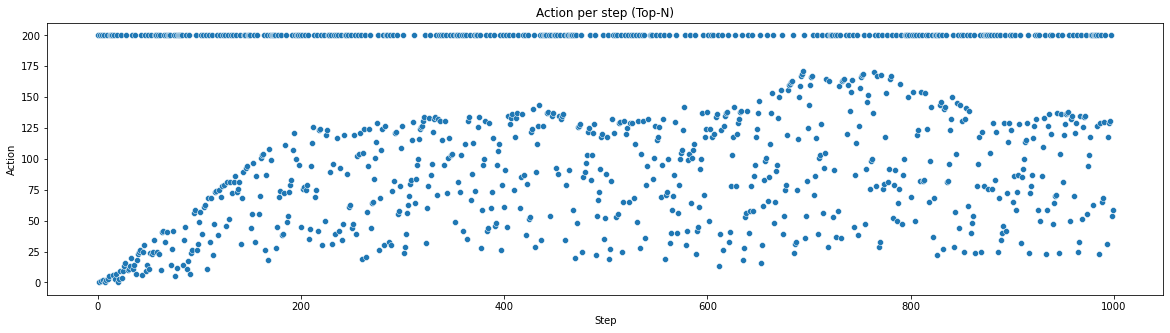

In [43]:
plot_action_probs(topN_result, limit, max_peaks, title='Action per step (Top-N)')

Plot rewards coloured by action probabilities

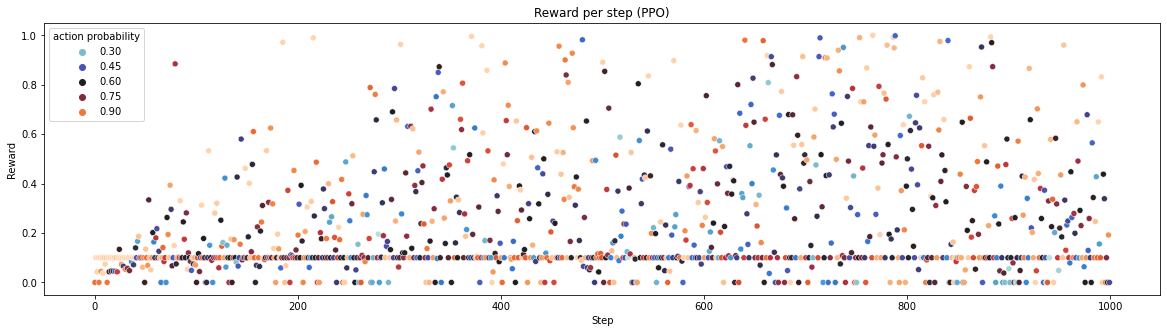

In [44]:
plot_reward_probs(ppo_result, limit, max_peaks, title='Reward per step (PPO)')

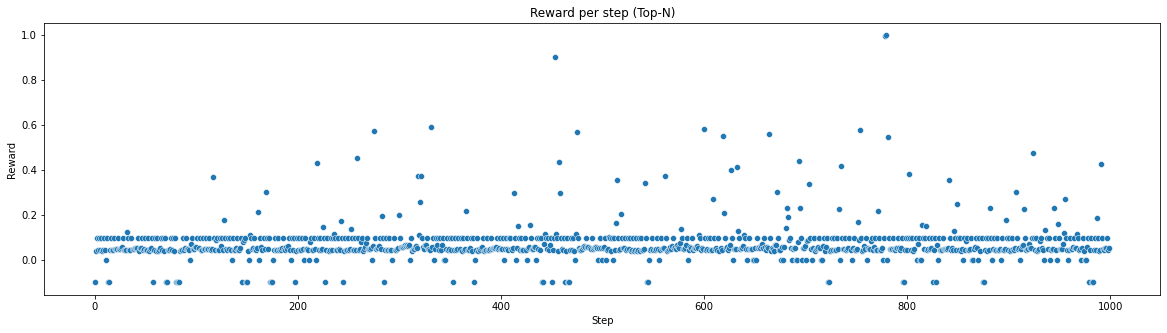

In [45]:
plot_reward_probs(topN_result, limit, max_peaks, title='Reward per step (Top-N)')